In [5]:
import matplotlib.pyplot as plt

from example.b92 import b92
from example.bb84 import bb84
from example.e91 import e91
from numpy import arange
from pychor import Party

# Eavesdropping detection

Visualize the results. Eve gets detected for any reasonable number of reads.

In [ ]:
# How many bits to attempt to generate?
N_BITS = 200
# What percentage of qubits will Eve read in the quantum channel?
EVE_READ_PCTS = [0.05, 0.10, 0.15, 0.20, 1.0]
# What percentage of good bits will BB84 and B92 use for validation?
CHECK_PCT = 0.1
# How many trials to run at each setting?
N_TRIALS = 10

alice = Party('alice')
bob = Party('bob')
eve = Party('eve')
source = Party('source')

Run each protocol a number of times for various eavesdropping rates.

In [7]:
n_checks = int(N_BITS * CHECK_PCT)
protocols = {
    'BB84': lambda pct: bb84(alice, bob, eve, N_BITS, n_checks, pct_eve=pct),
    'B92': lambda pct: b92(alice, bob, eve, N_BITS, n_checks, pct_eve=pct),
    'E91': lambda pct: e91(alice, bob, eve, source, N_BITS, pct_eve=pct),
}

detections = {name: [] for name in protocols}

for pct in EVE_READ_PCTS:
    for name, run_protocol in protocols.items():
        detected_count = 0
        for _ in range(N_TRIALS):
            _, _, a_detected, _ = run_protocol(pct)
            detected_count += a_detected.val
        detections[name].append(detected_count)


Visualize the results.

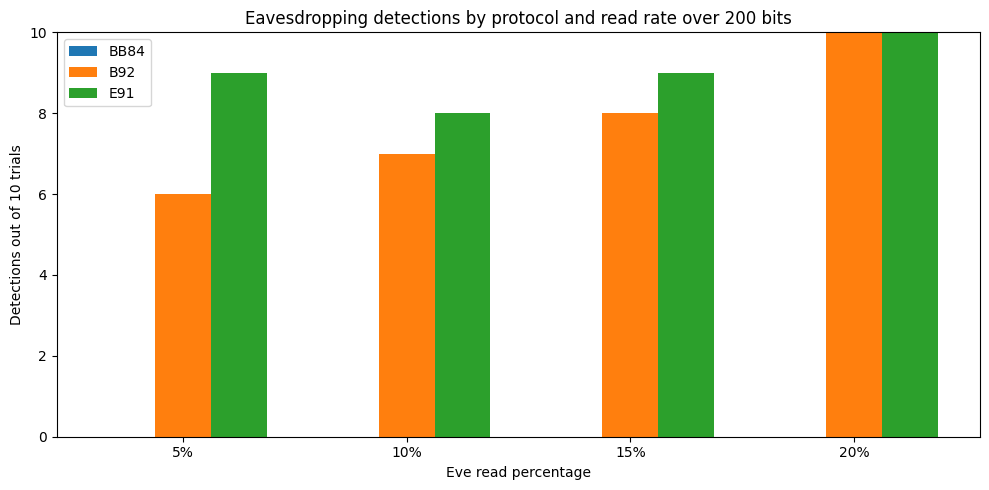

In [8]:

x = arange(len(EVE_READ_PCTS))
bar_width = 0.25

plt.figure(figsize=(10, 5))
for i, protocol in enumerate(detections):
    offsets = x + (i - 1) * bar_width
    plt.bar(offsets, detections[protocol], width=bar_width, label=protocol)

plt.xticks(x, [f"{int(p * 100)}%" for p in EVE_READ_PCTS])
plt.xlabel('Eve read percentage')
plt.ylabel(f'Detections out of {N_TRIALS} trials')
plt.title(f'Eavesdropping detections by protocol and read rate over {N_BITS} bits')
plt.ylim(0, N_TRIALS)
plt.legend()
plt.tight_layout()
plt.show()